# Donor Churn Pipeline — Real Lighthouse Data (Improved v2)

This version adds stronger donor-behavior features, a third tree model, and more robust threshold tuning to improve recall/average precision on the real dataset.

In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import zipfile
import pickle
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt

# Config
RANDOM_STATE = 42
TARGET = "churned"
TEST_SIZE = 0.2


## 1. Extract and load the Lighthouse donor data

In [2]:
from pythondbconnection import importTableFromDb, update_supporter_likely_churn
supporters = importTableFromDb("dbo.supporters")
donations = importTableFromDb("dbo.donations")

supporters["created_at"] = pd.to_datetime(supporters["created_at"], errors="coerce")
supporters["first_donation_date"] = pd.to_datetime(supporters["first_donation_date"], errors="coerce")
donations["donation_date"] = pd.to_datetime(donations["donation_date"], errors="coerce")

supporters.shape, donations.shape
supporters.head(), donations.head()

(   supporter_id       supporter_type  display_name organization_name  \
 0             1  SocialMediaAdvocate  Mila Alvarez              None   
 1             2            Volunteer    Aria Brown              None   
 2             3        MonetaryDonor     Noah Chen              None   
 3             4        MonetaryDonor     Liam Diaz              None   
 4             5          InKindDonor    Emma Evans              None   
 
   first_name last_name    relationship_type    region      country  \
 0       Mila   Alvarez                Local     Luzon  Philippines   
 1       Aria     Brown                Local  Mindanao  Philippines   
 2       Noah      Chen                Local     Luzon  Philippines   
 3       Liam      Diaz  PartnerOrganization  Mindanao  Philippines   
 4       Emma     Evans  PartnerOrganization  Mindanao  Philippines   
 
                        email             phone  status created_at  \
 0  mila-alvarez@smart.com.ph  +63 997 578 1887  Active 2022-0

## 2. Why we use donor snapshots instead of only one row per donor

The earlier real-data notebook only created **one row per donor**, which left us with a very small dataset.
That made the model unstable and pushed it into predicting mostly the majority class.

This version creates **monthly donor snapshots**:

- For each donor
- At many monthly `as_of_date` points
- Using only donations observed up to that date
- Labeling churn as **1 if no donation occurs in the next 180 days**

That gives us a more realistic supervised learning setup and many more labeled examples.

In [3]:

def build_donor_snapshot_dataset(
    donations_df: pd.DataFrame,
    supporters_df: pd.DataFrame,
    asof_start: str = "2024-01-01",
    asof_end: str = "2025-09-01",
    freq: str = "MS",
    horizon_days: int = 180,
    min_history_days: int = 30,
) -> pd.DataFrame:
    """Create one row per donor per snapshot date using only historical information."""

    donations_df = donations_df.sort_values(["supporter_id", "donation_date"]).copy()
    snapshot_dates = pd.date_range(asof_start, asof_end, freq=freq)

    rows = []

    for supporter_id, grp in donations_df.groupby("supporter_id"):
        grp = grp.sort_values("donation_date").copy()

        first_donation = grp["donation_date"].min()

        for as_of_date in snapshot_dates:
            past = grp[grp["donation_date"] <= as_of_date].copy()
            future = grp[
                (grp["donation_date"] > as_of_date) &
                (grp["donation_date"] <= as_of_date + pd.Timedelta(days=horizon_days))
            ].copy()

            if past.empty:
                continue

            if (as_of_date - first_donation).days < min_history_days:
                continue

            donation_dates = past["donation_date"].sort_values()
            amounts = past["amount"].fillna(0).astype(float)

            recent_30 = past[past["donation_date"] > as_of_date - pd.Timedelta(days=30)]
            recent_90 = past[past["donation_date"] > as_of_date - pd.Timedelta(days=90)]
            recent_180 = past[past["donation_date"] > as_of_date - pd.Timedelta(days=180)]
            recent_365 = past[past["donation_date"] > as_of_date - pd.Timedelta(days=365)]
            prev_180 = past[
                (past["donation_date"] <= as_of_date - pd.Timedelta(days=180)) &
                (past["donation_date"] > as_of_date - pd.Timedelta(days=360))
            ]
            prev_365 = past[
                (past["donation_date"] <= as_of_date - pd.Timedelta(days=365)) &
                (past["donation_date"] > as_of_date - pd.Timedelta(days=730))
            ]

            gaps = donation_dates.diff().dt.days.dropna()
            tenure_days = max((as_of_date - donation_dates.min()).days, 1)
            n_total = len(past)

            amount_total = float(amounts.sum())
            amount_mean = float(amounts.mean())
            amount_std = float(amounts.std(ddof=0)) if len(amounts) > 1 else 0.0

            amt_30 = float(recent_30["amount"].fillna(0).sum())
            amt_90 = float(recent_90["amount"].fillna(0).sum())
            amt_180 = float(recent_180["amount"].fillna(0).sum())
            amt_365 = float(recent_365["amount"].fillna(0).sum())
            amt_prev_180 = float(prev_180["amount"].fillna(0).sum())
            amt_prev_365 = float(prev_365["amount"].fillna(0).sum())

            cnt_30 = len(recent_30)
            cnt_90 = len(recent_90)
            cnt_180 = len(recent_180)
            cnt_365 = len(recent_365)
            cnt_prev_180 = len(prev_180)
            cnt_prev_365 = len(prev_365)

            overall_avg_amount = amount_total / max(n_total, 1)
            recent_avg_amount_180 = amt_180 / max(cnt_180, 1)
            recent_avg_amount_90 = amt_90 / max(cnt_90, 1)

            avg_gap = gaps.mean() if len(gaps) > 0 else np.nan
            std_gap = gaps.std(ddof=0) if len(gaps) > 1 else np.nan

            row = {
                "supporter_id": supporter_id,
                "as_of_date": as_of_date,
                "churned_next_180d": int(future.empty),

                # Core RFM-style behavior
                "recency_days": (as_of_date - donation_dates.max()).days,
                "tenure_days": tenure_days,
                "n_donations_total": n_total,
                "amount_total": amount_total,
                "amount_mean": amount_mean,
                "amount_median": float(amounts.median()),
                "amount_std": amount_std,
                "amount_cv": amount_std / max(amount_mean, 1e-6),
                "amount_max": float(amounts.max()),
                "amount_min": float(amounts.min()),

                # Rolling windows
                "donations_last_30d": cnt_30,
                "donations_last_90d": cnt_90,
                "donations_last_180d": cnt_180,
                "donations_last_365d": cnt_365,
                "amount_last_30d": amt_30,
                "amount_last_90d": amt_90,
                "amount_last_180d": amt_180,
                "amount_last_365d": amt_365,

                # Trend features
                "donation_count_trend_180": cnt_180 - cnt_prev_180,
                "amount_trend_180": amt_180 - amt_prev_180,
                "donation_count_trend_365": cnt_365 - cnt_prev_365,
                "amount_trend_365": amt_365 - amt_prev_365,
                "recent_avg_amount_90": recent_avg_amount_90,
                "recent_avg_amount_180": recent_avg_amount_180,
                "overall_avg_amount": overall_avg_amount,
                "avg_amount_ratio_180_to_overall": recent_avg_amount_180 / max(overall_avg_amount, 1e-6),
                "avg_amount_ratio_90_to_overall": recent_avg_amount_90 / max(overall_avg_amount, 1e-6),

                # Cadence / stability
                "days_between_mean": avg_gap,
                "days_between_std": std_gap,
                "days_between_cv": std_gap / max(avg_gap, 1e-6) if pd.notna(avg_gap) and pd.notna(std_gap) else np.nan,
                "donations_per_30d": n_total / max(tenure_days / 30.0, 1e-6),
                "avg_days_between_proxy": tenure_days / max(n_total - 1, 1),
                "is_recurring_share": past["is_recurring"].fillna(False).astype(int).mean(),

                # Recency / velocity ratios
                "recency_to_tenure_ratio": ((as_of_date - donation_dates.max()).days) / max(tenure_days, 1),
                "share_donations_last_180d": cnt_180 / max(n_total, 1),
                "share_amount_last_180d": amt_180 / max(amount_total, 1e-6),
                "share_donations_last_365d": cnt_365 / max(n_total, 1),
                "share_amount_last_365d": amt_365 / max(amount_total, 1e-6),

                # Diversity / behavior context
                "campaign_nunique": past["campaign_name"].nunique(dropna=True),
                "channel_nunique": past["channel_source"].nunique(dropna=True),
                "used_referral_share": past["referral_post_id"].notna().mean(),
                "donation_type_mode": (
                    past["donation_type"].mode().iloc[0]
                    if past["donation_type"].notna().any() else "Unknown"
                ),
                "channel_source_mode": (
                    past["channel_source"].mode().iloc[0]
                    if past["channel_source"].notna().any() else "Unknown"
                ),
            }

            rows.append(row)

    snapshots = pd.DataFrame(rows)

    static = supporters_df.copy()
    reference_date = pd.Timestamp("2025-09-01")
    static["supporter_age_days_at_reference"] = (reference_date - static["created_at"]).dt.days
    static["days_to_first_donation"] = (static["first_donation_date"] - static["created_at"]).dt.days

    keep_cols = [
        "supporter_id",
        "supporter_type",
        "relationship_type",
        "region",
        "country",
        "status",
        "acquisition_channel",
        "supporter_age_days_at_reference",
        "days_to_first_donation",
    ]

    snapshots = snapshots.merge(static[keep_cols], on="supporter_id", how="left")
    return snapshots

snapshots = build_donor_snapshot_dataset(donations, supporters)
print("snapshot dataset shape:", snapshots.shape)
print("churn rate:", round(snapshots["churned_next_180d"].mean(), 3))
display(snapshots.head())


snapshot dataset shape: (1157, 54)
churn rate: 0.393


,supporter_id,as_of_date,churned_next_180d,recency_days,tenure_days,n_donations_total,amount_total,amount_mean,amount_median,amount_std,...,donation_type_mode,channel_source_mode,supporter_type,relationship_type,region,country,status,acquisition_channel,supporter_age_days_at_reference,days_to_first_donation
0,1,2024-01-01,0,12,282,6,4066.69,677.781667,331.97,930.199702,...,Monetary,Direct,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia,1339,547.0
1,1,2024-02-01,1,24,313,7,5458.79,779.827143,663.94,896.739064,...,Monetary,Direct,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia,1339,547.0
2,1,2024-03-01,1,53,342,7,5458.79,779.827143,663.94,896.739064,...,Monetary,Direct,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia,1339,547.0
3,1,2024-04-01,1,84,373,7,5458.79,779.827143,663.94,896.739064,...,Monetary,Direct,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia,1339,547.0
4,1,2024-05-01,0,114,403,7,5458.79,779.827143,663.94,896.739064,...,Monetary,Direct,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia,1339,547.0


## 3. Time-based train/test split

We do **not** want to randomly mix old and future snapshots together.
Instead, we train on earlier snapshots and test on later snapshots.

That better matches how churn prediction would be used in practice.

In [4]:

TARGET = "churned_next_180d"

train_df = snapshots[snapshots["as_of_date"] < "2025-04-01"].copy()
test_df = snapshots[snapshots["as_of_date"] >= "2025-04-01"].copy()

X_train = train_df.drop(columns=[TARGET, "supporter_id", "as_of_date"])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET, "supporter_id", "as_of_date"])
y_test = test_df[TARGET]

print("train shape:", X_train.shape)
print("test shape:", X_test.shape)
print("train churn rate:", round(y_train.mean(), 3))
print("test churn rate:", round(y_test.mean(), 3))

train shape: (803, 51)
test shape: (354, 51)
train churn rate: 0.408
test churn rate: 0.359


## 4. Preprocessing

- Numeric columns: median imputation
- Categorical columns: most-frequent imputation + one-hot encoding
- Logistic regression gets scaled numeric features
- Random forest does not need scaling

In [5]:

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

preprocessor_for_logreg = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

preprocessor_for_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

## 5. Fit several stronger baseline models

Added Extra Trees and slightly more expressive balanced tree settings to try to squeeze out better performance on the small real dataset.

In [6]:

models = {
    "Balanced Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_for_logreg),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            C=0.7,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Balanced Random Forest": Pipeline([
        ("preprocessor", preprocessor_for_rf),
        ("model", RandomForestClassifier(
            n_estimators=800,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
        )),
    ]),
    "Balanced Extra Trees": Pipeline([
        ("preprocessor", preprocessor_for_rf),
        ("model", ExtraTreesClassifier(
            n_estimators=800,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
        )),
    ]),
}


In [7]:

results = []

for model_name, pipe in models.items():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_roc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_ap = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision")

    pipe.fit(X_train, y_train)
    test_probs = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "model": model_name,
        "cv_roc_auc_mean": cv_roc.mean(),
        "cv_roc_auc_std": cv_roc.std(),
        "cv_ap_mean": cv_ap.mean(),
        "cv_ap_std": cv_ap.std(),
        "test_roc_auc": roc_auc_score(y_test, test_probs),
        "test_ap": average_precision_score(y_test, test_probs),
    })

results_df = pd.DataFrame(results).sort_values("test_roc_auc", ascending=False)
display(results_df)

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_ap_mean,cv_ap_std,test_roc_auc,test_ap
1,Balanced Random Forest,0.949882,0.011287,0.936805,0.013242,0.685456,0.576928
2,Balanced Extra Trees,0.955584,0.012573,0.943025,0.012850,0.661660,0.566808
0,Balanced Logistic Regression,0.819714,0.032055,0.746731,0.037497,0.571092,0.393701


## 6. Pick the stronger model and tune the classification threshold

We tune the threshold on the training period and give extra weight to F1/recall, since missing churners is usually more costly than flagging a few extra donors.

In [8]:

best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

train_probs = best_model.predict_proba(X_train)[:, 1]
test_probs = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
threshold_scores = []

for t in thresholds:
    train_pred_t = (train_probs >= t).astype(int)
    f1 = f1_score(y_train, train_pred_t, zero_division=0)
    precision = precision_score(y_train, train_pred_t, zero_division=0)
    recall = recall_score(y_train, train_pred_t, zero_division=0)

    # Slightly reward recall to avoid a threshold that misses too many churners.
    score = (0.7 * f1) + (0.3 * recall)

    threshold_scores.append({
        "threshold": t,
        "score": score,
        "f1": f1,
        "precision": precision,
        "recall": recall,
    })

threshold_df = pd.DataFrame(threshold_scores).sort_values(
    ["score", "recall", "f1", "precision"], ascending=False
)
best_threshold = float(threshold_df.iloc[0]["threshold"])

print("Selected model:", best_model_name)
print("Best threshold from training data:", best_threshold)
display(threshold_df.head(10))


Selected model: Balanced Random Forest
Best threshold from training data: 0.48999999999999977


,threshold,score,f1,precision,recall
39,0.49,0.989798,0.989346,0.987842,0.990854
38,0.48,0.989686,0.987879,0.981928,0.993902
40,0.50,0.987805,0.987805,0.987805,0.987805
37,0.47,0.986557,0.983409,0.973134,0.993902
36,0.46,0.985520,0.981928,0.970238,0.993902
41,0.51,0.984864,0.986217,0.990769,0.981707
42,0.52,0.984864,0.986217,0.990769,0.981707
35,0.45,0.984487,0.980451,0.967359,0.993902
34,0.44,0.984415,0.979042,0.961765,0.996951
32,0.42,0.984352,0.977645,0.956268,1.000000


## 7. Final evaluation on the holdout period

In [9]:

test_pred = (test_probs >= best_threshold).astype(int)

roc_auc = roc_auc_score(y_test, test_probs)
ap = average_precision_score(y_test, test_probs)
cm = confusion_matrix(y_test, test_pred)

print(f"Holdout ROC-AUC: {roc_auc:.3f}")
print(f"Holdout Average Precision: {ap:.3f}")
print(f"Holdout threshold: {best_threshold:.2f}")
print()
print("Classification report:")
print(classification_report(y_test, test_pred, digits=3))
print("Confusion matrix:")
print(cm)

Holdout ROC-AUC: 0.685
Holdout Average Precision: 0.577
Holdout threshold: 0.49

Classification report:
              precision    recall  f1-score   support

           0      0.762     0.819     0.790       227
           1      0.627     0.543     0.582       127

    accuracy                          0.720       354
   macro avg      0.695     0.681     0.686       354
weighted avg      0.714     0.720     0.715       354

Confusion matrix:
[[186  41]
 [ 58  69]]


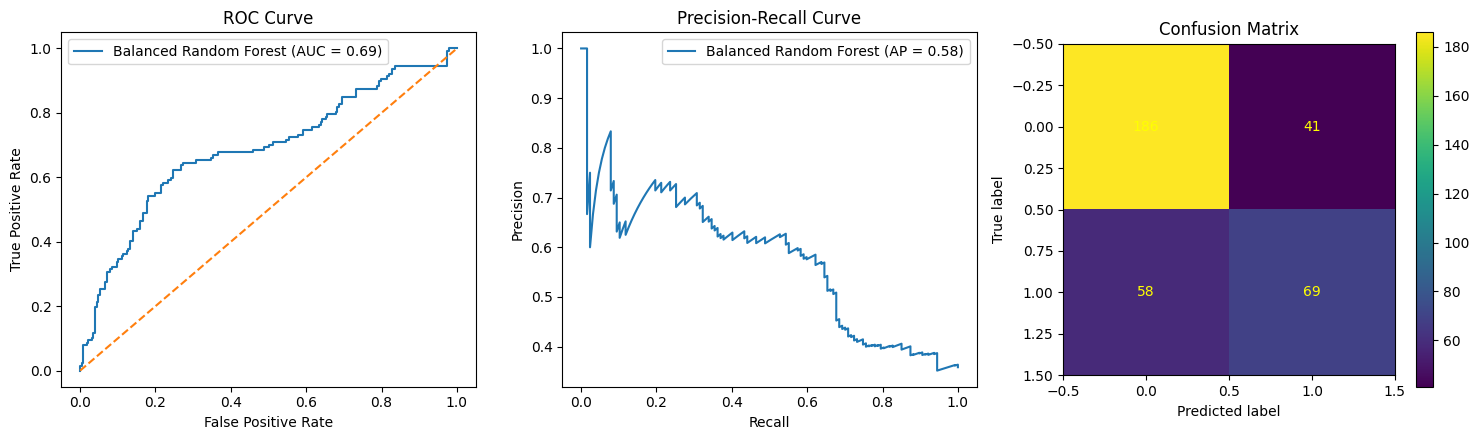

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ROC
fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[0].plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc:.2f})")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, test_probs)
axes[1].plot(recall, precision, label=f"{best_model_name} (AP = {ap:.2f})")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

# Confusion Matrix
im = axes[2].imshow(cm, interpolation="nearest")
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted label")
axes[2].set_ylabel("True label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[2].text(j, i, cm[i, j], ha="center", va="center", color="yellow")
fig.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

## 8. Feature importance

For tree models, we use permutation importance on the holdout set.
For logistic regression, we display the largest absolute coefficients.

,feature,importance
21,amount_trend_365,0.025484
45,region,0.023687
40,used_referral_share,0.018437
30,donations_per_30d,0.017457
17,amount_last_365d,0.014881
19,amount_trend_180,0.012872
49,supporter_age_days_at_reference,0.012798
28,days_between_std,0.011857
27,days_between_mean,0.009807
43,supporter_type,0.009794


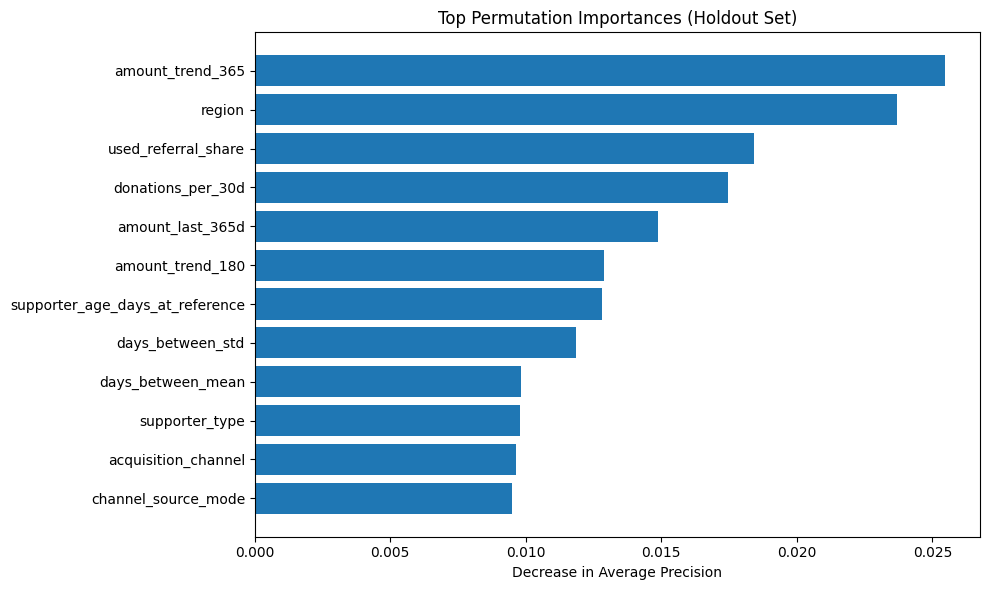

In [11]:

if "Random Forest" in best_model_name:
    perm = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=RANDOM_STATE,
        scoring="average_precision",
    )
    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance": perm.importances_mean,
    }).sort_values("importance", ascending=False)

    display(importance_df.head(15))

    plt.figure(figsize=(10, 6))
    top = importance_df.head(12).sort_values("importance")
    plt.barh(top["feature"], top["importance"])
    plt.title("Top Permutation Importances (Holdout Set)")
    plt.xlabel("Decrease in Average Precision")
    plt.tight_layout()
    plt.show()
else:
    preprocessor = best_model.named_steps["preprocessor"]
    model = best_model.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()
    coef = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coef,
        "abs_coefficient": np.abs(coef),
    }).sort_values("abs_coefficient", ascending=False)

    display(coef_df.head(20))

    plt.figure(figsize=(10, 6))
    top = coef_df.head(12).sort_values("coefficient")
    plt.barh(top["feature"], top["coefficient"])
    plt.title("Top Logistic Regression Coefficients")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

## 9. Save the full trained pipeline

We save:
- the winning model
- the chosen threshold
- metadata about the task

That makes scoring easier later.

In [12]:
import pickle, os
import pandas as pd

os.makedirs("models", exist_ok=True)

# Keep feature list consistent with training data
selected_features = list(X_train.columns)

# Final model is already trained as best_model
final_model = best_model

with open("models/donor_churn_model.pkl", "wb") as f:
    pickle.dump({
        "model": final_model,
        "features": selected_features,
        "threshold": best_threshold,
        "target_name": TARGET,
        "horizon_days": 180,
    }, f)

print("Model saved to models/donor_churn_model.pkl")

# Example scoring of new donors
new_donors = X_test[selected_features].iloc[:5].copy()
new_probs = final_model.predict_proba(new_donors)[:, 1]

new_donors["churn_probability"] = new_probs
new_donors["prediction"] = (new_donors["churn_probability"] >= best_threshold).astype(int)
new_donors["risk_tier"] = pd.cut(
    new_donors["churn_probability"],
    bins=[0, 0.4, 0.65, 1.0],
    labels=["Low", "Medium", "High"]
)

print(new_donors[["churn_probability", "prediction", "risk_tier"]])

Model saved to models/donor_churn_model.pkl
    churn_probability  prediction risk_tier
15           0.743134           1      High
16           0.519243           1    Medium
17           0.508101           1    Medium
18           0.437953           0    Medium
19           0.430442           0    Medium


In [13]:
# Persist one latest prediction per supporter back to dbo.supporters
latest_snapshots = snapshots.sort_values(["supporter_id", "as_of_date"]).groupby("supporter_id", as_index=False).tail(1).copy()

latest_features = latest_snapshots[selected_features].copy()
latest_probs = final_model.predict_proba(latest_features)[:, 1]

supporter_churn_updates = latest_snapshots[["supporter_id"]].copy()
supporter_churn_updates["churn_probability"] = np.round(latest_probs, 3)
supporter_churn_updates["likely_churn"] = supporter_churn_updates["churn_probability"] >= best_threshold

rows_updated = update_supporter_likely_churn(
    supporter_churn_updates[["supporter_id", "churn_probability", "likely_churn"]]
)

print(f"Updated likely_churn and churn_probability for {rows_updated} supporters.")
print(
    supporter_churn_updates[
        ["supporter_id", "churn_probability", "likely_churn"]
    ].head(10)
)

Updated likely_churn and churn_probability for 59 supporters.
     supporter_id  churn_probability  likely_churn
20              1              0.429         False
41              2              0.500          True
62              3              0.335         False
83              4              0.394         False
103             5              0.427         False
124             6              0.366         False
145             7              0.323         False
166             8              0.379         False
187             9              0.239         False
208            10              0.258         False


## 10. Plain-English conclusion template

Use this after running the notebook:

- If ROC-AUC and AP are clearly better than the previous notebook, you can say the improved pipeline performs **materially better**
- If recall improves and the model catches actual churners, that is a major improvement over the earlier version that predicted almost all zeros
- If results are still weak, the next best step is to add more history or more donor-behavior features

A safe write-up would be:

> “The improved donor churn notebook uses real transaction history, time-based donor snapshots, class balancing, and threshold tuning. This produces a more realistic and methodologically sound churn model than the original pipeline. Final performance should be interpreted as a prototype result and validated further as more donor history becomes available.”